In [8]:
import json, gzip
from pathlib import Path
from typing import List, Dict, Any, Tuple
import numpy as np
import pandas as pd

def _open_text(path: Path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt", encoding="utf-8")
    return open(path, "r", encoding="utf-8")

def load_training_log(path: str) -> pd.DataFrame:
    """
    Supporta:
    - JSON array: [{"epoch":1,"train_loss":...,"val_loss":...,"train_acc":...,"val_acc":...}, ...]
    - JSONL: una riga JSON per epoch
    - Campi opzionali: "lr", "time_sec", ecc.
    Ritorna un DataFrame ordinato per epoch.
    """
    p = Path(path)
    with _open_text(p) as f:
        first = f.read(1)
        f.seek(0)
        if first.strip().startswith("["):
            data = json.load(f)                 # JSON array
        else:
            data = [json.loads(line) for line in f if line.strip()]  # JSONL
    df = pd.DataFrame(data)
    # Normalizza nomi colonne comuni
    rename_map = {
        "train_accuracy":"train_acc",
        "val_accuracy":"val_acc",
        "training_loss":"train_loss",
        "validation_loss":"val_loss",
    }
    df = df.rename(columns=rename_map)
    if "epoch" in df.columns:
        df = df.sort_values("epoch").reset_index(drop=True)
    else:
        df["epoch"] = np.arange(1, len(df)+1)
    return df

def load_predictions_json(path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Supporta due formati:
    A) {"y_true":[...], "y_pred":[...]} (opzionalmente "y_prob":[[...], ...])
    B) [{"true":int, "pred":int, "prob":[...]} , ...]
    Ritorna (y_true, y_pred, y_prob) dove y_prob può essere None.
    """
    p = Path(path)
    with _open_text(p) as f:
        first = f.read(1); f.seek(0)
        obj = json.load(f) if first.strip().startswith("{") else [json.loads(l) for l in f if l.strip()]
    y_true = y_pred = y_prob = None
    if isinstance(obj, dict):
        y_true = np.array(obj.get("y_true"), dtype=int)
        y_pred = np.array(obj.get("y_pred"), dtype=int)
        if "y_prob" in obj:
            y_prob = np.array(obj["y_prob"], dtype=float)
    else:
        y_true = np.array([r.get("true") for r in obj], dtype=int)
        y_pred = np.array([r.get("pred") for r in obj], dtype=int)
        if any("prob" in r for r in obj):
            y_prob = np.array([r.get("prob") for r in obj], dtype=float)
    return y_true, y_pred, y_prob


In [9]:
import matplotlib.pyplot as plt

def plot_learning_curves(df_log: pd.DataFrame, savepath: str=None):
    """
    df_log: DataFrame con colonne epoch, train_loss, val_loss, train_acc, val_acc.
    """
    # --- Loss ---
    plt.figure()
    if "train_loss" in df_log: plt.plot(df_log["epoch"], df_log["train_loss"], label="train_loss")
    if "val_loss"   in df_log: plt.plot(df_log["epoch"], df_log["val_loss"],   label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Learning Curve — Loss"); plt.legend()
    plt.grid(True, alpha=0.3)
    if savepath: plt.savefig(f"{savepath}_loss.png", dpi=160, bbox_inches="tight")
    plt.show()

    # --- Accuracy ---
    has_acc = ("train_acc" in df_log) or ("val_acc" in df_log)
    if has_acc:
        plt.figure()
        if "train_acc" in df_log: plt.plot(df_log["epoch"], df_log["train_acc"], label="train_acc")
        if "val_acc"   in df_log: plt.plot(df_log["epoch"], df_log["val_acc"],   label="val_acc")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Learning Curve — Accuracy"); plt.legend()
        plt.grid(True, alpha=0.3)
        if savepath: plt.savefig(f"{savepath}_acc.png", dpi=160, bbox_inches="tight")
        plt.show()


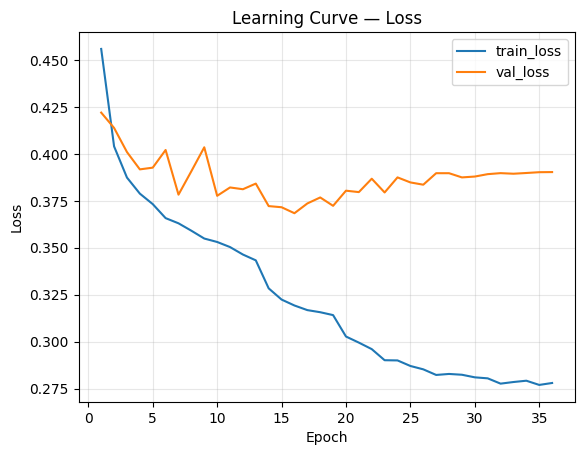

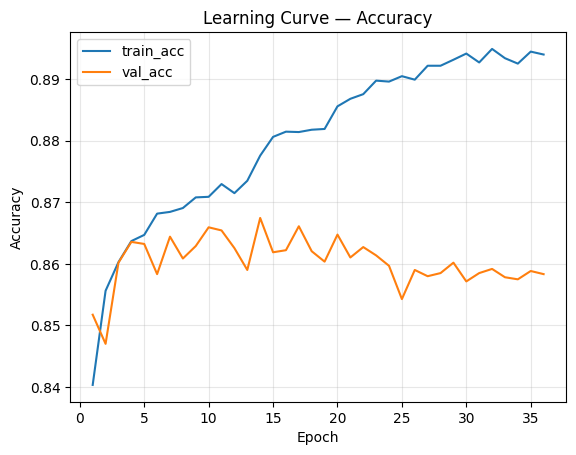

<Figure size 640x480 with 0 Axes>

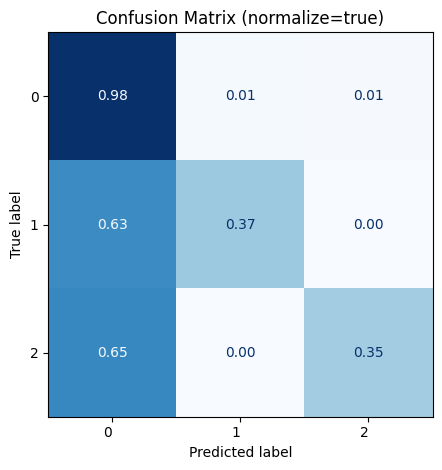

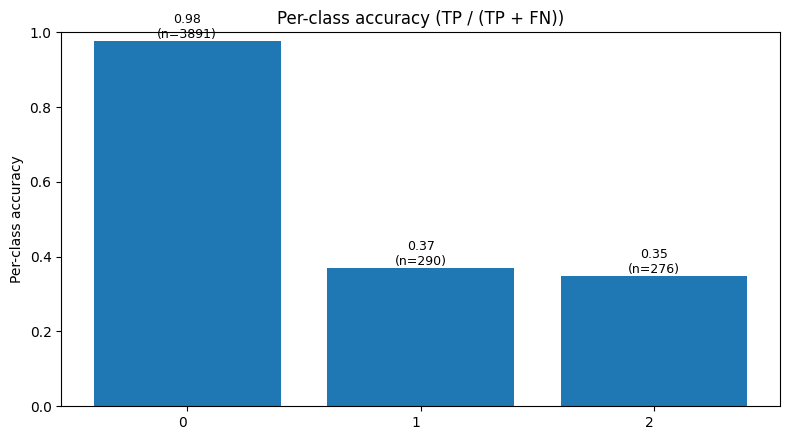

,class,support,accuracy
0,0,3891,0.977898
1,1,290,0.368966
2,2,276,0.347826


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def confusion_and_per_class_acc(y_true: np.ndarray, y_pred: np.ndarray, class_names=None, normalize=None):
    """
    Mostra la confusion matrix (eventualmente normalizzata) e un grafico a barre
    con la per-class accuracy. Restituisce anche la confusion matrix "raw" (non
    normalizzata) e una tabella per-classe con supporto e accuracy.

    normalize: None | 'true' | 'pred' | 'all'
    """
    # Etichette/ordine coerente per CM e tabella
    if class_names is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
        class_names_for_disp = [str(c) for c in labels]
    else:
        labels = np.array(class_names)
        class_names_for_disp = class_names

    # Confusion matrix (con opzione di normalizzazione)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_for_disp)
    plt.figure()
    disp.plot(values_format=".2f" if normalize else "d", cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix{'' if not normalize else f' (normalize={normalize})'}")
    plt.xticks(ha="right")
    plt.tight_layout()
    plt.show()

    # Confusion matrix raw (non normalizzata) per calcolare la per-class accuracy
    cm_raw = confusion_matrix(y_true, y_pred, labels=labels, normalize=None)
    row_sum = cm_raw.sum(axis=1).astype(float)
    per_class_acc = np.divide(np.diag(cm_raw), row_sum, out=np.zeros_like(row_sum, dtype=float), where=row_sum > 0)

    # Tabella per-classe
    per_class_df = pd.DataFrame({
        "class": [str(c) for c in labels],
        "support": row_sum.astype(int),
        "accuracy": per_class_acc
    }).sort_values("class").reset_index(drop=True)

    # --- Grafico della per-class accuracy ---
    # Usiamo l'ordine alfabetico come nella tabella ordinata sopra
    classes_plot = per_class_df["class"].values
    acc_plot = per_class_df["accuracy"].values
    support_plot = per_class_df["support"].values

    plt.figure(figsize=(8, 4.5))
    bars = plt.bar(classes_plot, acc_plot)
    plt.ylabel("Per-class accuracy")
    plt.ylim(0, 1.0)
    plt.title("Per-class accuracy (TP / (TP + FN))")
    plt.xticks(ha="right")
    # Annotazioni con valore accuracy e supporto
    for rect, acc, supp in zip(bars, acc_plot, support_plot):
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2.0, height,
                 f"{acc:.2f}\n(n={supp})",
                 ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

    return cm_raw, per_class_df

# Esempio d'uso (lasciato invariato):
df_log = load_training_log("../logs/train_log.jsonl")
plot_learning_curves(df_log)

y_true, y_pred, y_prob = load_predictions_json("../logs/test_predictions.json")
cm_raw, per_class_df = confusion_and_per_class_acc(y_true, y_pred, class_names=None, normalize="true")
per_class_df
